# Info Extraction
- Fetch key info from API
- Get Financial Statements and data related to the past 30 days
- Get Quarterly Data

## Verify
- Statements are released on the same day
- Determine analysis period for stock_hist_info()

## Improvement
- FMP contains stats from anaylist maybe we could also use those

In [248]:
import requests
import pandas as pd

class API:

    KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"
    BASE_URL = "https://financialmodelingprep.com/stable/"
    
    # Might need to track number of API CALLS PER MINUTE
    
    def fetch(endpoint="", query=""):
        url = f"{API.BASE_URL}{endpoint}?{query}&apikey={API.KEY}"
        print(f"request url:{url}\n")
        response = requests.get(url)
        json_response = response.json() 
        return pd.DataFrame(json_response)
           
    def download_sp500_constituent_info():
        df_constituent_full_info = API.fetch("sp500-constituent")
        df_constituent_full_info.set_index('symbol', inplace=True)
        df_constituent_light_info = df_constituent_full_info[['sector','subSector']] 
        df_constituent_light_info.to_csv('sp500_constituent.csv')

    # The "date" in the responses of fetch_ticker_key_metrics() and fetch_ticker_financial_ratios() represents the end date of the period the financial statement covers 
    def fetch_ticker_key_metrics(symbol,period="quarter"):
        endpoint = "key-metrics"
        query = f"symbol={symbol}&period={period}"
        df_key_metrics = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_key_metrics)

    def fetch_ticker_financial_ratios(symbol,period="quarter"):
        endpoint = "ratios"
        query = f"symbol={symbol}&period={period}"
        df_financial_ratio = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_financial_ratio)

    # For fetch price --> get the full list and then process in order to reduce the number of API calls
    def fetch_ticker_hist_price(symbol):
        endpoint = "historical-price-eod/full"
        query = f"symbol={symbol}"
        df_hist_price = API.fetch(endpoint,query)
        return API.set_index_and_sort(df_hist_price)
    
    def set_index_and_sort(df,index="date"):
        df.set_index('date', inplace=True)
        df.index = pd.to_datetime(df.index)
        df = df.sort_index(ascending=True)
        return df

class Signals: #Maybe change name to SignalExtraction 

    EXCLUDE_COLS = ['symbol','fiscalYear','period','reportedCurrency'] 

    # def get_growth_key_metrics(symbol,period="quarter"):
    #     df_key_metrics_raw = API.fetch_ticker_key_metrics(symbol,period) # change to quarterly!
    #     df_growth_key_metrics = df_key_metrics_raw[FeatureConstruction.EXCLUDE_COLS]
    #     df_temp = df_key_metrics_raw.drop(columns=FeatureConstruction.EXCLUDE_COLS).pct_change(1)
    #     new_columns_names = ["delta"+name[0].upper() + name[1:] for name in df_temp.columns]
    #     df_temp.columns = new_columns_names
    #     df_growth_key_metrics.loc[:,df_temp.columns] = df_temp # Need to write it this way to avoid warning
    #     return df_growth_key_metrics

    # def get_growth_financial_ratios(symbol,period="quarter"):
    #     df_ratios_raw = API.fetch_ticker_financial_ratios(symbol,period) # change to quarterly!
    #     df_growth_ratios = df_ratios_raw[FeatureConstruction.EXCLUDE_COLS]
    #     df_temp = df_ratios_raw.drop(columns=FeatureConstruction.EXCLUDE_COLS).pct_change(1)
    #     new_columns_names = ["delta"+name[0].upper() + name[1:] for name in df_temp.columns]
    #     df_temp.columns = new_columns_names
    #     df_growth_ratios.loc[:,df_temp.columns] = df_temp # Need to write it this way to avoid warning
    #     return df_growth_ratios
    
    def growth_statements_info(symbol,period='quarter',num_periods_compared=1):
        df_growth_info_raw = API.fetch_ticker_financial_ratios(symbol,period)
        df_metrics_raw = API.fetch_ticker_key_metrics(symbol,period) 

        df_growth_info_raw.merge(df_metrics_raw,on='date')
        df_growth_info = df_growth_info_raw[Signals.EXCLUDE_COLS]

        for gap in range(1,num_periods_compared+1):
            df_p_growth = df_growth_info_raw.drop(columns=Signals.EXCLUDE_COLS).pct_change(gap)
            new_columns_names = [name+"_"+str(gap)+"p" for name in df_p_growth.columns]
            df_p_growth.columns = new_columns_names
            df_growth_info.loc[:,df_p_growth.columns] = df_p_growth
        return df_growth_info
    
    def stock_insight(symbol): # Determine Analysis Period
        df_hist_raw = API.fetch_ticker_hist_price(symbol)

        # For dataframe subtractions collumns must have same names. This is not the case for series
        closing_price = df_hist_raw['close']
        low_price = df_hist_raw['low']
        high_price = df_hist_raw['high']
        volume = df_hist_raw["volume"]

        # Return
        ret_1d = closing_price.pct_change()
        ret_5d = closing_price.pct_change(5)
        ret_10d = closing_price.pct_change(10)

        # Volatility
        vol_5d = closing_price.pct_change().shift(1).rolling(window=5).std()
        vol_10d = closing_price.pct_change().shift(1).rolling(window=10).std()

        # Momentum
        momentum_10d = closing_price - closing_price.shift(10)

        # MFV
        mfm = ((closing_price-low_price) - (high_price-closing_price))/(high_price-low_price)
        mfv = mfm * volume
        ad_line = mfv.cumsum()
        AD_momentum_5d = ad_line.pct_change(5)
        AD_momentum_10d = ad_line.pct_change(10)
        AD_momentum_20d = ad_line.pct_change(20)

        # SMA Ratio
        sma_10 = closing_price.shift(1).rolling(window=10).mean()
        sma_50 = closing_price.shift(1).rolling(window=50).mean()
        sma_ratio = sma_10/sma_50

        # Z-score (20d)
        rolling_mean = closing_price.shift(1).rolling(window=20).mean()
        rolling_std = closing_price.shift(1).rolling(window=20).std()
        z_score_20d = (closing_price - rolling_mean)/rolling_std

        # RSI (14d)
        delta = closing_price.diff()
        gain = delta.where(delta > 0, 0.0)
        loss = -delta.where(delta < 0, 0.0)

        avg_gain = gain.shift(1).rolling(window=14).mean()
        avg_loss = loss.shift(1).rolling(window=14).mean()

        rs = avg_gain/avg_loss
        rsi_14 = 100 - (100 / (1 + rs))
        
        dataframes = [
        (ret_1d, 'ret_1d'),
        (ret_5d, 'ret_5d'),
        (ret_10d, 'ret_10d'),
        (vol_5d, 'vol_5d'),
        (vol_10d, 'vol_10d'),
        (momentum_10d, 'momentum_10d'),
        (sma_ratio, 'sma_ratio_10_50'),
        (z_score_20d, 'zscore_20d'),
        (rsi_14, 'rsi_14'),
        (volume,'volume'),
        (AD_momentum_5d,'AD_momentum_5d'),
        (AD_momentum_10d,'AD_momentum_10d'),
        (AD_momentum_20d,'AD_momentum_20d')
        ]


        for column, name in dataframes:
            column.name = name

        df_stock_insight = pd.concat(
            [column for column, _ in dataframes],
            axis=1
        )

        return df_stock_insight


request url:https://financialmodelingprep.com/stable/historical-price-eod/full?symbol=AAPL&apikey=wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4

request url:https://financialmodelingprep.com/stable/ratios?symbol=AAPL&period=anual&apikey=wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4

request url:https://financialmodelingprep.com/stable/key-metrics?symbol=AAPL&period=anual&apikey=wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4

(1261, 76)


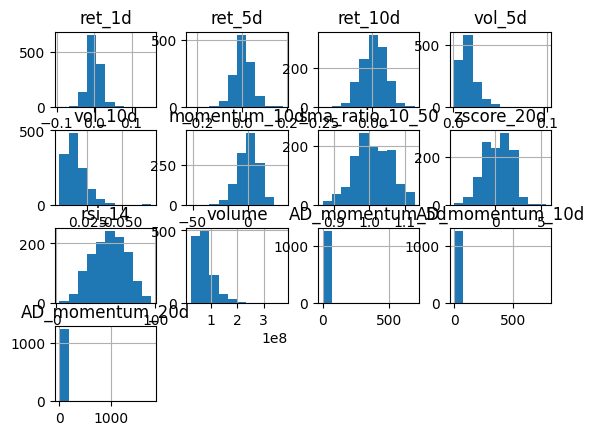

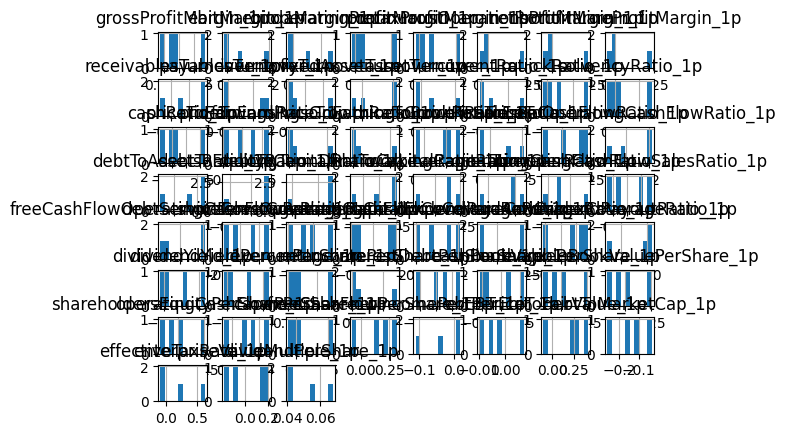

In [ ]:
# NEED TO ALIGN DATA PROPERLY
#print(Signals.get_growth_key_metrics("AAPL","anual"))
#growth_info = Signals.growth_statements_info("AAPL",'anual')
#growth_info.head()
df_stock_insight = Signals.stock_insight('AAPL')
df_growth_info = Signals.growth_statements_info("AAPL",'anual')
df_features = pd.concat([df_growth_info,df_stock_insight],axis=1)
print(df_features.shape)
df_features.to_csv('data.csv')


# Feature Construction
- Need to perform this for Balance Sheet, Income Statement and Historical Stock Price
- Need a way to handle a variety of stocks (ticker feature)

In [242]:
# Feature Construction
from sklearn.base import BaseEstimator, TransformerMixin

# Need to perform this for Balance Sheet, Income Statement and Historical Stock Price
class TechnicalIndicatorTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X): # X are the fundamental values needed to calculate all the other features
        df = X.copy()
        
        # Create many features inside one transformer
        df['sma_10'] = df['close'].rolling(10).mean()
        df['sma_50'] = df['close'].rolling(50).mean()
        df['rsi'] = compute_rsi(df['close'])
        df['macd'] = compute_macd(df['close'])
        df['lag_1'] = df['close'].shift(1)
        df['volatility'] = df['close'].rolling(10).std()
        # ... up to 140 features

        return df # handle NaNs from rolling/shift

# Data Cleaning + PreProcessing
- NaN values will be dropped

In [ ]:
from sklearn.pipeline import FeatureUnion, Pipeline

transformer1 = Pipeline([
    ('imputer', SimpleImputer()),
    ('scaler', StandardScaler())
])

transformer2 = Pipeline([
    ('pca', PCA(n_components=5))
])


# Feature Ranking